In [1]:
%pip install onboard-methane-detection onnxruntime georeader-spaceml netCDF4 matplotlib numpy gdown


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Prepare data

In [2]:
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from georeader.readers import emit
import gdown

# Replace with your actual File ID and desired output file name
file_id = '1N4dS6oQ8ZdCl0-nx-uYefGqvXH_Ju_34'
scene_path = 'EMIT_L1B_RAD_001_20230824T070101_2323605_011.nc'

# gdown handles the direct link formatting and virus scan bypass automatically
gdown.download(id=file_id, output=scene_path, quiet=False)

print("Download complete!")

ds = netCDF4.Dataset(scene_path)


wavelengths = ds.groups["sensor_band_parameters"].variables["wavelengths"][:]
fwhms = ds.groups["sensor_band_parameters"].variables["fwhm"][:]
ds.close()

rst = emit.EMITImage(str(scene_path))
image = rst.load_raw() # Shape: (C, H, W)
acquired_images = [image]  # Simulating a list of acquired images



Downloading...
From (original): https://drive.google.com/uc?id=1N4dS6oQ8ZdCl0-nx-uYefGqvXH_Ju_34
From (redirected): https://drive.google.com/uc?id=1N4dS6oQ8ZdCl0-nx-uYefGqvXH_Ju_34&confirm=t&uuid=d00a6f3f-505b-443e-85fc-d169563ce440
To: /home/jherec/onboard-methane-detection/EMIT_L1B_RAD_001_20230824T070101_2323605_011.nc
100%|██████████| 1.85G/1.85G [01:29<00:00, 20.8MB/s]


Download complete!


# Onground preparation

In [3]:
# Core imports for on-ground processing
import numpy as np
from onboard_methane_detection import (
    select_the_bands_by_transmittance, 
    generate_methane_spectrum, 
    select_rgb_bands
)

# 1. Define or load sensor specifications
# wavelengths = [...]  # List of all available sensor wavelengths
# fwhms = [...]        # List of corresponding FWHMs

# 2. Select RGB bands
rgb_wavelengths, rgb_indices = select_rgb_bands(wavelengths)

# 3. Select bands specifically for Methane detection
# First, generate the baseline CH4 spectrum across all sensor bands
ch4_spectrum_full = generate_methane_spectrum(wavelengths, fwhms)

# Then, select the most informative bands based on transmittance
selected_wvs_ch4, selected_ch4_spectrum = select_the_bands_by_transmittance(
    wavelengths, ch4_spectrum_full, N=50, strategy="highest-variance"
)
selected_indices_ch4 = [wavelengths.tolist().index(w) for w in selected_wvs_ch4]

# 4. Export artifacts for the onboard inference session
np.save('rgb_indices.npy', np.array(rgb_indices))
np.save('selected_indices_ch4.npy', np.array(selected_indices_ch4))
np.save('selected_ch4_spectrum.npy', selected_ch4_spectrum)

In [4]:
print("Selected RGB wavelengths:", rgb_wavelengths)
print("Selected CH4 detection wavelengths (first 10):", selected_wvs_ch4[:10])
print("Selected CH4 spectrum values (first 10):", selected_ch4_spectrum[:10])

Selected RGB wavelengths: [641.27587891 551.86669922 462.59887695]
Selected CH4 detection wavelengths (first 10): [ 641.2759 2345.1216 2359.9126 2337.7263 2197.097  2241.5269 1662.6074
 2352.517  2367.3071 2204.5034]
Selected CH4 spectrum values (first 10): [ 0.         -1.45539884 -0.72685826 -1.06426885 -0.33007281 -0.52952338
 -0.16260012 -1.30541219 -0.92341418 -0.42849208]


# Onboard session

In [5]:
import numpy as np

# Core imports for onboard execution
from onboard_methane_detection import (
    mag1c_sas,
    initialize_model,
    normalize_image,
    model_inference
)

# 1. Load exported artifacts (indices and spectrum) from On-Ground preparation
rgb_indices = np.load('rgb_indices.npy')
selected_indices_ch4 = np.load('selected_indices_ch4.npy')
selected_ch4_spectrum = np.load('selected_ch4_spectrum.npy')

# 2. Session Initialization
# Initialize the inference model before the processing loop begins
session, input_name = initialize_model(dynamic_output_size=True)

# 3. Processing Images (Onboard Loop)
# acquired_images: list of images in shape (C, H, W)

for image in acquired_images:
    # Extract RGB channels using previously found indices
    rgb_image = image[rgb_indices, :, :]
    
    # Extract the CH4 detection bands from the image
    methane_bands_image = image[selected_indices_ch4, :, :]
    
    # Apply Mag1c SAS preprocessing.
    # Optional tiling args (`tiling`, `tile_size`) can be used if the image is too large.
    mag1c_output = mag1c_sas(methane_bands_image, selected_ch4_spectrum, tiling=False)
    
    # Concatenate Mag1c SAS output with local RGB context.
    # Correct channel order is R, G, B, Mag1c-SAS.
    model_input = np.concatenate([rgb_image, mag1c_output], axis=0)
    
    # Normalize input: sensor_or_factors can be "emit", "aviris_ng", 
    # or a custom array of 4 division factors for a different sensor.
    model_input = normalize_image(model_input, sensor_or_factors='emit') 
    
    # Run model inference.
    # Tiling arguments can also be provided here if the image is too large.
    predictions = model_inference(session, input_name, model_input, use_tiling=False, logits_to_probs=True)
    
    print("Processed image and generated predictions.")

Using model: linknet_exported_dynamic.onnx
Processed image and generated predictions.


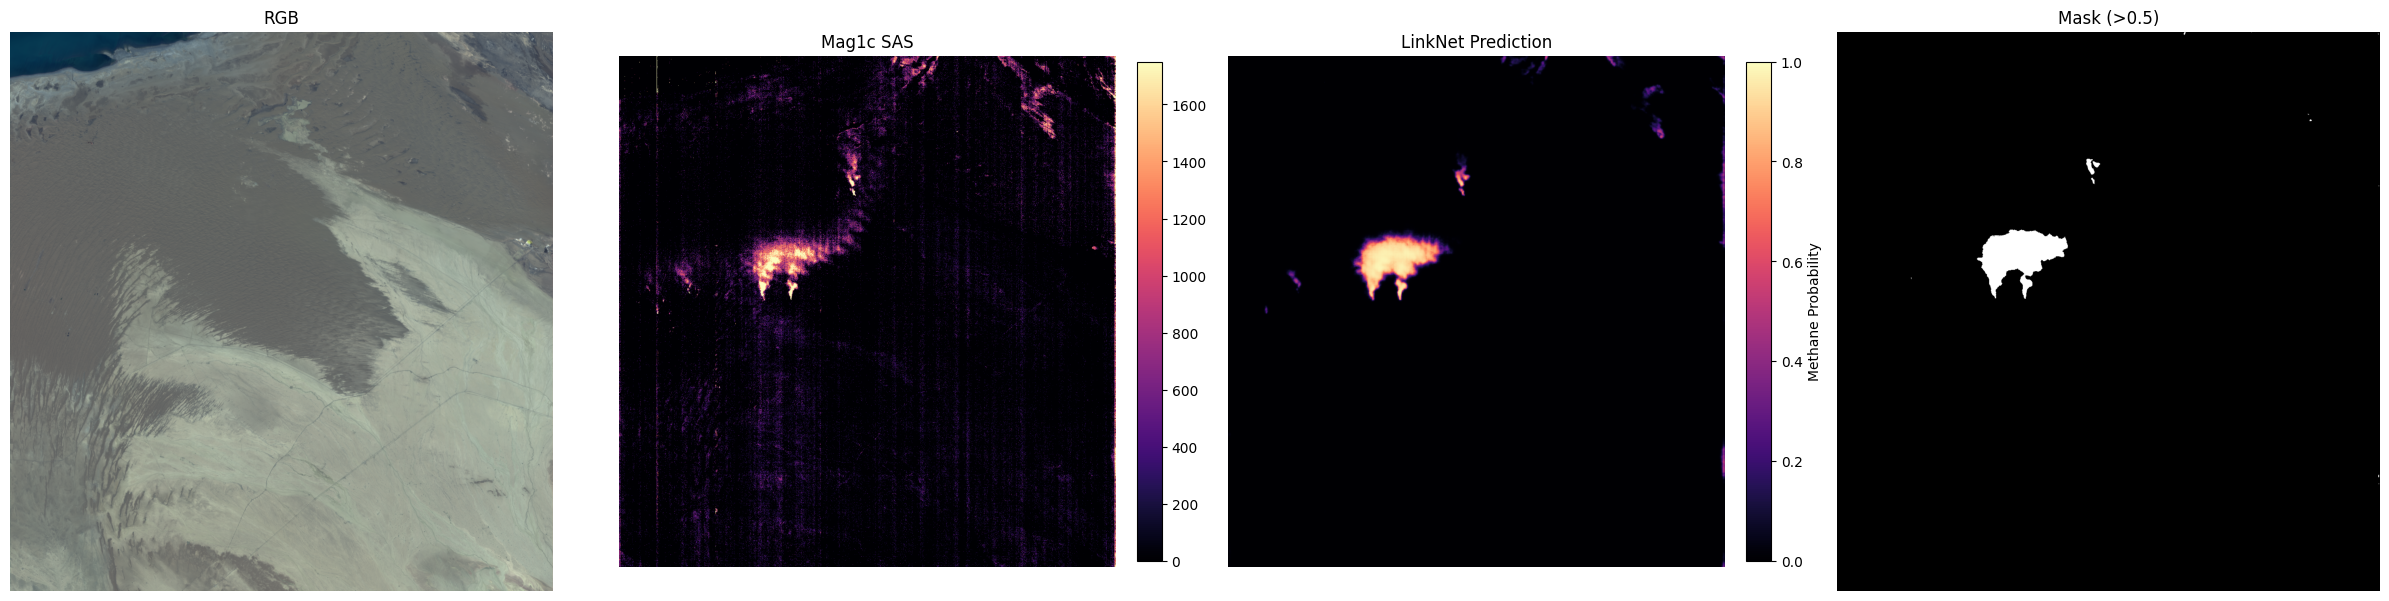

In [6]:
plt.figure(figsize=(24, 6))

# Plot 1: RGB Context
plt.subplot(1, 4, 1)
# Transpose (C, H, W) to (H, W, C) and normalize for basic viewing
rgb_display = np.transpose(rgb_image, (1, 2, 0))
rgb_display = (rgb_display - np.nanmin(rgb_display)) / (np.nanmax(rgb_display) - np.nanmin(rgb_display) + 1e-8)
plt.imshow(rgb_display)
plt.title("RGB")
plt.axis('off')

# Plot 2: Mag1c SAS Output
plt.subplot(1, 4, 2)
mag1c_display = mag1c_output.squeeze()
vmin, vmax = 0, 1750
im_mag1c = plt.imshow(mag1c_display, cmap='magma', vmin=vmin, vmax=vmax)
plt.colorbar(im_mag1c, fraction=0.046, pad=0.04)
plt.title("Mag1c SAS")
plt.axis('off')

# Plot 3: Inference Predictions
plt.subplot(1, 4, 3)
pred_display = predictions.squeeze()
im_pred = plt.imshow(pred_display, cmap='magma', vmin=0, vmax=1)
plt.colorbar(im_pred, fraction=0.046, pad=0.04, label='Methane Probability')
plt.title("LinkNet Prediction")
plt.axis('off')

# Plot 4: Thresholded Mask (0.5)
plt.subplot(1, 4, 4)
mask = (pred_display > 0.5).astype(np.uint8)
plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
plt.title("Mask (>0.5)")
plt.axis('off')

plt.tight_layout()
plt.show()